# ARTI 402 — Deep Learning
## Lab 1 — From a Single Neuron to a Layer

**Week 1 · Introduction to Deep Learning**
History, motivations and applications of deep learning; neural-network architecture and terminology.

| | |
|---|---|
| **Marks** | **1 mark** (graded) |
| **Estimated time** | 90–120 minutes |
| **Prerequisites** | Basic Python (lists, loops, functions) |


---

### How to work through the notebook

* Sections are labelled **Idea** (read and run), **Exercise** (you write code) and **Checkpoint** (a short answer).
* Every exercise cell is marked `# TODO`. Do not delete the cells above it — later cells depend on them.
* Run cells **in order**, top to bottom. If something breaks, restart the kernel and run all.
* The graded **Assessment** is at the very end.

---

### By the end of this lab you should be able to

1. Use the vocabulary of deep learning correctly: *feature, sample, batch, label, weight, bias, layer*.
2. Compute the output of a single neuron in plain Python.
3. Explain what a **weight** does and what a **bias** does, and show it on a graph.
4. Compute the output of a whole layer — first with loops, then with NumPy.
5. Predict the **shape** of every array in a forward pass before you run it.
6. Count the trainable parameters of a fully connected network.


---
## Setup

Run this cell first. If it fails, fix it before going any further — every other cell depends on it.


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

print("Python     :", sys.version.split()[0])
print("NumPy      :", np.__version__)

# Makes everyone's random numbers identical, so your results match the answer key.
np.random.seed(0)

# Prints arrays with 4 decimals and no scientific notation - much easier to read.
np.set_printoptions(precision=4, suppress=True)

print("\nSetup OK")

Python     : 3.13.5
NumPy      : 2.3.5

Setup OK


---
## Idea 1 — Where does "deep learning" actually sit?

These four words get used interchangeably, and they are not the same thing. They are **nested**:


![Alt text](http://www.eitc.org/research-opportunities/photos8/ai-vs-ml-vs-dl-vs-neural-networks_120924a)


The word **deep** has a definition: a network with **two or more hidden
layers** is deep. That is the whole test.

### A very short history

| When | What happened |
|---|---|
| 1943 | McCulloch & Pitts publish the first mathematical model of a neuron |
| 1958 | Rosenblatt builds the **Perceptron** — a single neuron that learns |
| 1969 | Minsky & Papert show a single perceptron cannot even learn XOR → funding dries up |
| 1960s–70s | The mathematics behind **backpropagation** is worked out |
| 1986 | Rumelhart, Hinton & Williams popularise backpropagation for neural networks |
| 1998 | LeCun's **LeNet-5** reads handwritten digits on real bank cheques |
| 2012 | **AlexNet** wins the ImageNet competition by a huge margin, on GPUs. Everything changes |
| 2014 | **GANs** — networks that generate convincing fake images |
| 2017 | The **Transformer** architecture ("Attention Is All You Need") |
| 2020s | Large language models and diffusion models reach the general public |

Notice the 26-year gap between backpropagation becoming well known (1986) and deep learning
taking over (2012). The algorithm was not the bottleneck.

### So why *now*?

Three things had to arrive together:

1. **Data.** The internet produced labelled datasets large enough to train on. ImageNet alone
   has over a million labelled photographs.
2. **Compute.** GPUs were built to render video games, and it turned out that rendering
   triangles and multiplying matrices are the same kind of work.
3. **Algorithms.** Better activation functions, better initialisation, better optimisers,
   better regularisation. You will implement most of these yourself over the next twelve weeks.

### What it is used for

Self-driving cars, credit-risk scoring, fraud detection, early cancer detection from scans,
image captioning, machine translation, speech recognition, protein-structure prediction,
and the chatbots you have all already used.

### The two questions you must always ask about a task

**Question 1 — do we have labels?**

* **Supervised learning** — yes, every example comes with the correct answer attached.
* **Unsupervised learning** — no labels; the model has to find structure on its own.

**Question 2 — what kind of answer do we want?**

* **Classification** — a *category*. Cat or dog. Fraud or legitimate. One of ten digits.
* **Regression** — a *number*. Tomorrow's temperature. The price of a house.

### Checkpoint 1

For each task, say whether it is **classification**, **regression** or **unsupervised**.

1. Predicting tomorrow's maximum temperature in Dammam from this week's weather data.
2. Deciding whether an X-ray shows pneumonia or not.
3. Grouping 50,000 customers into "shopper types" that nobody defined in advance.
4. Estimating how many minutes a delivery will take.


> **Your answers:**
>
> 1. *(Regression)*
> 2. *(Classification)*
> 3. *(Unsupervised)*
> 4. *(Regression)*


---
## Idea 2 — The vocabulary you cannot avoid

Every dataset in this course is a table. Learn to read it the way a neural network does.

Imagine a server room with three sensors, read every ten minutes:

| | temperature | humidity | fan speed | status |
|---|---|---|---|---|
| reading 1 | 22.5 | 41.0 | 1200 | normal |
| reading 2 | 23.1 | 40.2 | 1180 | normal |
| reading 3 | 38.9 | 55.7 | 2400 | failure |
| reading 4 | 41.2 | 58.1 | 2600 | failure |

* A **feature** is one column — one thing you measured. `temperature` is a feature.
* A **feature set** is one row *without* the answer: `[22.5, 41.0, 1200]`.
* A **sample** (also *observation*, also *instance*) is one row. Four rows here means four samples.
* A **label** is the answer for that row — `normal` or `failure`. Also called the **target** or
  the **ground truth**.
* A **batch** is a group of samples fed through the network together. All four rows at once
  would be a batch of size 4.

Two conventions used everywhere, including this course:

* **`X`** (capital) holds the features — one row per sample.
* **`y`** (lowercase) holds the labels — one entry per sample.

Networks only do arithmetic, so labels have to become numbers too. Here: `normal = 0`, `failure = 1`.


### Exercise 1 — put the table into arrays

Build `X` and `y` from the table above, then report the counts.

Use `0` for `normal` and `1` for `failure`.


In [2]:
# TODO: build X as a list of lists - one inner list per sample, features in the
#       order (temperature, humidity, fan_speed).
X =  [
    [22.5, 41.0, 1200],
    [23.1, 40.2, 1180],
    [38.9, 55.7, 2400],
    [41.2, 58.1, 2600]
]

# TODO: build y as a flat list of labels: normal -> 0, failure -> 1
y = [0, 0, 1, 1]

# TODO: how many samples are there? How many features per sample?
#       Compute these from X - do not just type 4 and 3.
n_samples = len(X)
n_features = len(X[0])

print("X =", X)
print("y =", y)
print(f"{n_samples} samples, {n_features} features each")

# --- self-check ---
assert n_samples == 4,  f"expected 4 samples, got {n_samples}"
assert n_features == 3, f"expected 3 features, got {n_features}"
assert len(y) == n_samples, "you need exactly one label per sample"
assert set(y) == {0, 1}, "labels should be 0 and 1"
print("Exercise 1 passed")

X = [[22.5, 41.0, 1200], [23.1, 40.2, 1180], [38.9, 55.7, 2400], [41.2, 58.1, 2600]]
y = [0, 0, 1, 1]
4 samples, 3 features each
Exercise 1 passed


---
## Idea 3 — A single neuron

Here is the entire neuron. There is nothing hidden.

A neuron receives some **inputs**. Each input has its own **weight**. The neuron multiplies each
input by its weight, adds everything up, then adds one **bias**:

$$\text{output} = (x_1 w_1 + x_2 w_2 + \dots + x_n w_n) + b$$

Or in plain words: *multiply, sum, add the bias.* That's it.

Two facts to hold on to:

* One weight **per input**. Three inputs means three weights.
* One bias **per neuron**. Not per input — per neuron. Always exactly one.

The inputs come either from your data (first layer) or from the previous layer's neurons
(every other layer). The weights and the bias are the **parameters** — the numbers that get
learned during training. In a real network there are millions of them, all being nudged.


In [3]:
# A single neuron with 3 inputs.
inputs  = [1, 2, 3]
weights = [0.2, 0.8, -0.5]
bias    = 2

output = (inputs[0] * weights[0] +
          inputs[1] * weights[1] +
          inputs[2] * weights[2] + bias)

print(output)

2.3


Trace it by hand once — it is worth the thirty seconds:

```
1 * 0.2  =  0.2
2 * 0.8  =  1.6
3 * -0.5 = -1.5
           -----
sum      =  0.3
+ bias 2 =  2.3
```

Notice the third weight is **negative**. That input actively pushes the output *down*.
Negative weights are not errors — they are how a network learns that some evidence argues
*against* a conclusion.


### Exercise 2 — a neuron with four inputs

Add a fourth input and its weight. Nothing else about the neuron changes.

```
inputs  = [1.0, 2.0, 3.0, 2.5]
weights = [0.2, 0.8, -0.5, 1.0]
bias    = 2.0
```


In [4]:
inputs  = [1.0, 2.0, 3.0, 2.5]
weights = [0.2, 0.8, -0.5, 1.0]
bias    = 2.0

# TODO: compute the neuron output the same way as above, but with 4 terms.
output = (
    inputs[0] * weights[0] +
    inputs[1] * weights[1] +
    inputs[2] * weights[2] +
    inputs[3] * weights[3] +
    bias
)

print("output =", output)

# --- self-check ---
assert abs(output - 4.8) < 1e-9, f"expected 4.8, got {output}"
print("Exercise 2 passed")

output = 4.8
Exercise 2 passed


---
## Idea 4 — Weights and biases are just knobs

Take the simplest possible neuron: one input, one weight, one bias.

$$\text{output} = w \cdot x + b$$

You have seen this before. It is $y = mx + c$ — the equation of a straight line, from previous course such as Linear Algebra :)

* The **weight** is the slope. It **tilts** the line.
* The **bias** is the intercept. It **shifts** the line up or down.

Run the cell and look at the two plots. This picture is worth more than the equation.


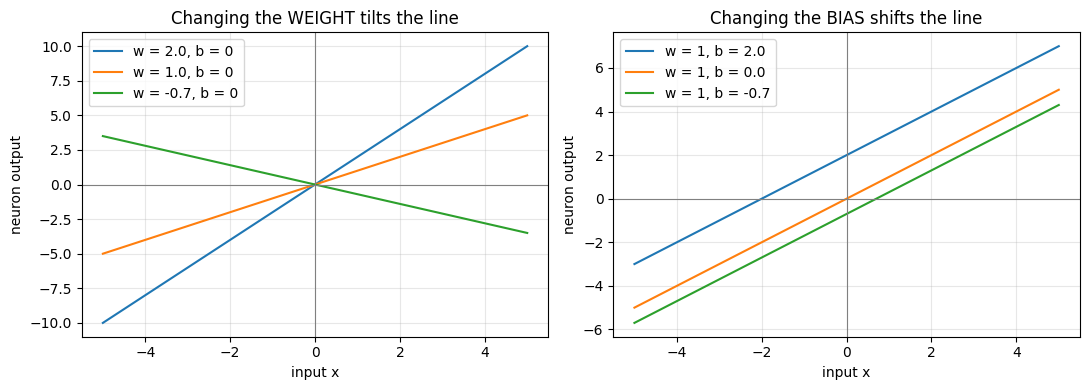

In [5]:
x = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# LEFT: change the weight, keep the bias at 0
for w in [2.0, 1.0, -0.7]:
    axes[0].plot(x, w * x + 0.0, label=f"w = {w}, b = 0")
axes[0].set_title("Changing the WEIGHT tilts the line")

# RIGHT: change the bias, keep the weight at 1
for b in [2.0, 0.0, -0.7]:
    axes[1].plot(x, 1.0 * x + b, label=f"w = 1, b = {b}")
axes[1].set_title("Changing the BIAS shifts the line")

for ax in axes:
    ax.axhline(0, color="grey", lw=0.8)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_xlabel("input x")
    ax.set_ylabel("neuron output")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Look at the left plot. Every single line passes through the origin, no matter what the
weight is. Without a bias, a neuron **cannot** produce a non-zero output from a zero input.
That is a real limitation, and it is the entire reason the bias exists.

Now look at the right plot. The bias lifts the whole line off the origin, which lets the neuron
fire even when the input is small.

Training a network means turning millions of these knobs at once until the output is right.


### Exercise 3 — your own knobs

Write the one-input neuron as a function, then plot it with a **negative weight** and a
**positive bias** so you can see both effects at the same time.


Exercise 3 passed


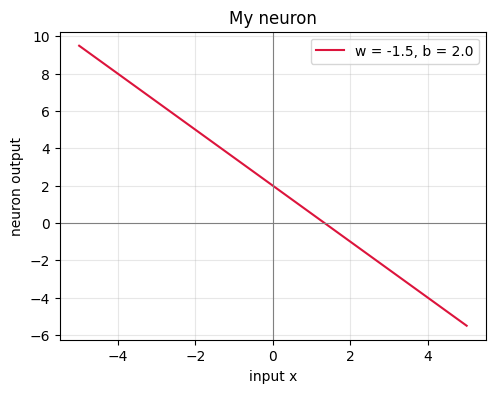

In [6]:
# TODO: return the output of a single-input neuron: weight * x + bias
def neuron_line(x, w, b):
        return w * x + b


# --- self-check ---
assert abs(neuron_line(2.0, 3.0, 1.0) - 7.0) < 1e-9, "neuron_line(2, 3, 1) should be 7.0"
assert abs(neuron_line(0.0, 5.0, -2.0) + 2.0) < 1e-9, "at x=0 the output should equal the bias"
print("Exercise 3 passed")

# TODO: pick a negative weight and a positive bias, then plot the line.
my_w = -1.5
my_b = 2.0

plt.figure(figsize=(5.5, 4))
plt.plot(x, neuron_line(x, my_w, my_b), color="crimson",
         label=f"w = {my_w}, b = {my_b}")
plt.axhline(0, color="grey", lw=0.8)
plt.axvline(0, color="grey", lw=0.8)
plt.xlabel("input x")
plt.ylabel("neuron output")
plt.title("My neuron")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Checkpoint 2

In one sentence each:

1. What does the **weight** control?
2. What does the **bias** control?
3. Why can a neuron with no bias never output a non-zero value when the input is 0?


> **Your answers:**
>
> 1. *(The weight controls the slope of the line)*
> 2. *(The bias shifts the line up or down)*
> 3. *(With no bias, when the input is 0, the output is always 0)*


---
## Idea 5 — Firing or not: the step function

The original inspiration was a brain cell that either fires or does not. In code, that
on/off behaviour is a **step function**:

$$\text{step}(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{otherwise} \end{cases}$$

So a complete neuron is really two stages:

```
z      = sum(inputs * weights) + bias      # the linear part
output = activation(z)                     # the decision
```

That second function is the **activation function**, and it is the subject of Lab 2. Modern
networks almost never use a step function — you will meet ReLU, sigmoid and softmax next week —
but the step function is the clearest possible starting point, and it is where the field
literally began in 1943.


### Exercise 4 — implement the step function

Then apply it to some neuron outputs and see which neurons "fire".


In [7]:
# TODO: return 1 if x is greater than 0, otherwise return 0
def step(x):
        return 1 if x > 0 else 0


# --- self-check ---
assert step(3.4) == 1, "positive input should fire"
assert step(-1.2) == 0, "negative input should not fire"
assert step(0) == 0, "exactly zero should NOT fire (we use strictly greater than)"
print("Exercise 4 passed")

# Some pretend neuron outputs
z_values = [2.3, -0.5, 0.0, 4.8, -3.1]

# TODO: build a list with step() applied to every value in z_values
fired = [step(z) for z in z_values]

for z, f in zip(z_values, fired):
    print(f"z = {z:>5}  ->  {'FIRES' if f else 'silent'}")

Exercise 4 passed
z =   2.3  ->  FIRES
z =  -0.5  ->  silent
z =   0.0  ->  silent
z =   4.8  ->  FIRES
z =  -3.1  ->  silent


---
## Idea 6 — A layer of neurons

A **layer** is just a group of neurons that all see the same input.

Each neuron in the layer:

* receives the **same** inputs as every other neuron in the layer,
* has its **own** set of weights,
* has its **own** bias,
* produces its **own** output.

So a layer of 3 neurons fed by 4 inputs turns 4 numbers into 3 numbers. It needs
3 × 4 = 12 weights and 3 biases.

When every neuron is connected to every input like this, the layer is called **dense**, or
**fully connected**. It is the layer you will use most often in this course.


In [8]:
inputs = [1, 2, 3, 2.5]

# One row of weights per neuron.
weights1 = [ 0.2,   0.8,  -0.5,   1  ]   # neuron 1
weights2 = [ 0.5,  -0.91,  0.26, -0.5]   # neuron 2
weights3 = [-0.26, -0.27,  0.17,  0.87]  # neuron 3

# One bias per neuron.
bias1, bias2, bias3 = 2, 3, 0.5

outputs = [
    # Neuron 1:
    inputs[0]*weights1[0] + inputs[1]*weights1[1] +
    inputs[2]*weights1[2] + inputs[3]*weights1[3] + bias1,
    # Neuron 2:
    inputs[0]*weights2[0] + inputs[1]*weights2[1] +
    inputs[2]*weights2[2] + inputs[3]*weights2[3] + bias2,
    # Neuron 3:
    inputs[0]*weights3[0] + inputs[1]*weights3[1] +
    inputs[2]*weights3[2] + inputs[3]*weights3[3] + bias3,
]

print(outputs)

[4.8, 1.21, 2.385]


That works, and it is unreadable. Imagine writing it for a layer of 512 neurons.

The pattern is obvious though: *for each neuron, for each input, multiply and accumulate.*
Two nested loops.


### Exercise 5 — the same layer, with loops

Rewrite the layer above using loops so it works for **any** number of neurons and inputs.

Two hints:

* `zip(weights, biases)` walks through the neurons, giving you one weight-row and its bias.
* `zip(inputs, neuron_weights)` walks through that neuron's inputs and weights together.
* Add the bias **once per neuron**, *after* the inner loop finishes — not inside it.


In [9]:
inputs = [1, 2, 3, 2.5]

weights = [[ 0.2,   0.8,  -0.5,   1  ],
           [ 0.5,  -0.91,  0.26, -0.5],
           [-0.26, -0.27,  0.17,  0.87]]

biases = [2, 3, 0.5]

layer_outputs = []

# TODO: loop over each neuron (its weight row and its bias)
for neuron_weights, neuron_bias in zip(weights, biases):

    neuron_output = 0

    # TODO: loop over this neuron's inputs and weights, multiply and accumulate
    for n_input, weight in zip(inputs, neuron_weights):
            neuron_output = 0

    # TODO: add the bias, then append the result to layer_outputs
    for n_input, weight in zip(inputs, neuron_weights):
        neuron_output += n_input * weight

    neuron_output += neuron_bias
    layer_outputs.append(neuron_output)

print(layer_outputs)

# --- self-check ---
expected = [4.8, 1.21, 2.385]
assert len(layer_outputs) == 3, f"a 3-neuron layer produces 3 outputs, got {len(layer_outputs)}"
for got, want in zip(layer_outputs, expected):
    assert abs(got - want) < 1e-9, f"expected {expected}, got {layer_outputs}"
print("Exercise 5 passed")

[4.8, 1.21, 2.385]
Exercise 5 passed


---
## Idea 7 — Arrays, shapes, and why "TensorFlow" is called that

Loops are clear but slow. NumPy is fast, and every deep-learning framework is built on the
same ideas. Before using it, get the vocabulary straight.

| Name | What it is | Example |
|---|---|---|
| **Scalar** | a single number | `5` |
| **Vector** | a 1-D array — a plain list of numbers | `[1, 5, 6, 2]` |
| **Matrix** | a 2-D array — rows and columns | `[[4, 2], [5, 1], [8, 2]]` |
| **Tensor** | an array of any number of dimensions | anything above, or deeper |

For this course: **a tensor is anything you can represent as an array.** That is genuinely all
the thought it needs. TensorFlow is named for the fact that it does operations on these things.

### Shape

The **shape** is a tuple giving the size of each dimension, from outermost to innermost.

`[[4, 2], [5, 1], [8, 2]]` has shape `(3, 2)` — 3 rows, 2 columns.

Read it by counting brackets: how many items in the outer bracket? That is the first number.
How many in each inner bracket? That is the second. And so on.

### One rule about arrays

An array must be **homologous**: every list at the same depth must have the same length.

```python
[[4, 2, 3],
 [5, 1]]        # NOT a valid array - rows of length 3 and 2
```

This matters more than it sounds. "Rows have different lengths" is one of the most common
errors you will hit when loading real data, and now you know what it means.


### Exercise 6 — predict the shape *before* you run it

This habit will save you hours later in the course. Write your prediction, **then** check it.


In [10]:
a = [1, 5, 6, 2]

b = [[4, 2],
     [5, 1],
     [8, 2]]

c = [[[1, 5, 6, 2], [3, 2, 1, 3]],
     [[5, 2, 1, 2], [6, 4, 8, 4]],
     [[2, 8, 5, 3], [1, 1, 9, 4]]]

# TODO: write your PREDICTION for each shape as a tuple, e.g. (3, 2)
#       Do this before running the cell. No peeking.
predicted_a = (4,)
predicted_b = (3, 2)
predicted_c = (3, 2, 4)

# Now check against reality.
actual_a = np.array(a).shape
actual_b = np.array(b).shape
actual_c = np.array(c).shape

for name, pred, act in [("a", predicted_a, actual_a),
                        ("b", predicted_b, actual_b),
                        ("c", predicted_c, actual_c)]:
    mark = "correct" if pred == act else f"not quite - it is {act}"
    print(f"{name}: you said {pred}  ->  {mark}")

# --- self-check ---
assert predicted_a == actual_a and predicted_b == actual_b and predicted_c == actual_c, \
    "Fix your predictions above so they match, then re-run."
print("Exercise 6 passed")

a: you said (4,)  ->  correct
b: you said (3, 2)  ->  correct
c: you said (3, 2, 4)  ->  correct
Exercise 6 passed


---
## Idea 8 — The dot product

Look again at what a neuron does:

```python
inputs[0]*weights[0] + inputs[1]*weights[1] + inputs[2]*weights[2] + ...
```

*Multiply matching elements, then add them all up.* Mathematics already has a name for that
operation: the **dot product**.

$$\vec{a} \cdot \vec{b} = a_1 b_1 + a_2 b_2 + \dots + a_n b_n$$

Two rules:

* Both vectors must have the **same length**.
* The result is a **single number** — a scalar.

So the linear part of a neuron *is* a dot product, plus a bias. NumPy gives us `np.dot()`.


In [13]:
a = [1, 2, 3]
b = [2, 3, 4]

print("by hand :", a[0]*b[0] + a[1]*b[1] + a[2]*b[2])
print("np.dot  :", np.dot(a, b))

by hand : 20
np.dot  : 20


### Exercise 7 — a single neuron, the NumPy way

Same neuron as Exercise 2. Same answer. One line instead of four.


In [11]:
inputs  = [1.0, 2.0, 3.0, 2.5]
weights = [0.2, 0.8, -0.5, 1.0]
bias    = 2.0

# TODO: use np.dot() and add the bias. One line.
output = np.dot(inputs, weights) + bias

print("output =", output)

# --- self-check ---
assert abs(output - 4.8) < 1e-9, f"expected 4.8, got {output}"
print("Exercise 7 passed - and it matches Exercise 2 exactly")

output = 4.8
Exercise 7 passed - and it matches Exercise 2 exactly


---
## Idea 9 — A whole layer, on a whole batch

Two upgrades at once. Take them one at a time.

### Upgrade 1: a layer instead of a neuron

The weights become a **matrix** — one row per neuron. `np.dot()` handles a matrix and a vector
by taking the dot product of each row with the vector, giving one number per neuron.


In [12]:
inputs = [1.0, 2.0, 3.0, 2.5]

weights = [[ 0.2,   0.8,  -0.5,   1.0 ],
           [ 0.5,  -0.91,  0.26, -0.5 ],
           [-0.26, -0.27,  0.17,  0.87]]

biases = [2.0, 3.0, 0.5]

layer_outputs = np.dot(weights, inputs) + biases

print(layer_outputs)
print("shape:", layer_outputs.shape)

[4.8   1.21  2.385]
shape: (3,)


Three lines replaced the whole double loop from Exercise 5, and the answer is identical.

### Upgrade 2: a batch instead of one sample

Real training never feeds one sample at a time. It feeds a **batch**, for two reasons:

1. **Speed.** Your hardware is built to do many multiplications in parallel. One sample at a
   time wastes almost all of it.
2. **Better learning.** Adjusting the network from one example makes it chase that example.
   Averaging over a batch produces changes that suit the dataset as a whole.

So `inputs` becomes a matrix too — one row per sample:

```python
inputs = [[ 1.0, 2.0,  3.0,  2.5],
          [ 2.0, 5.0, -1.0,  2.0],
          [-1.5, 2.7,  3.3, -0.8]]     # shape (3, 4): 3 samples, 4 features
```

### The problem: shapes do not line up

Now both sides are matrices, and `np.dot()` on two matrices is a **matrix product**: dot
products of every row of the left with every column of the right.

For that to work, **the inner dimensions must match**:

```
inputs  (3, 4)   x   weights (3, 4)      ->   4 != 3     ERROR
            ^                 ^
            +-----------------+  these must be equal (Rows of input == columns of weights)
```

### The fix: transpose

**Transposing** flips rows into columns. In NumPy it is `.T`:

```
weights   (3, 4)  --.T-->  weights.T  (4, 3)

inputs  (3, 4)   x   weights.T (4, 3)   ->   4 == 4      works, result is (3, 3)
            ^                   ^
            +-------------------+
```

The result has shape **(3 samples, 3 neurons)** — exactly what we want: one row per sample,
one column per neuron. Note the order swapped too: `np.dot(inputs, weights.T)`, not
`np.dot(weights, inputs)`. We put `inputs` first because we want the *samples* on the rows.

**The rule, once, so you can reuse it forever:** the inner dimensions must match, and the
outer dimensions are what survives into the result.


In [14]:
w = np.array([[1, 2, 3],
              [4, 5, 6]])

print("w        shape", w.shape)
print(w)
print()
print("w.T      shape", w.T.shape)
print(w.T)

w        shape (2, 3)
[[1 2 3]
 [4 5 6]]

w.T      shape (3, 2)
[[1 4]
 [2 5]
 [3 6]]


### Exercise 8 — the full batched layer

Push all 3 samples through the 3-neuron layer in a single expression.

**Before you write any code, work out the answer to this:** the output should have shape
`(____, ____)`. Fill that in in your head first.


In [16]:
inputs = [[ 1.0, 2.0,  3.0,  2.5],
          [ 2.0, 5.0, -1.0,  2.0],
          [-1.5, 2.7,  3.3, -0.8]]

weights = [[ 0.2,   0.8,  -0.5,   1.0 ],
           [ 0.5,  -0.91,  0.26, -0.5 ],
           [-0.26, -0.27,  0.17,  0.87]]

biases = [2.0, 3.0, 0.5]

# NumPy needs real arrays to use .T
inputs  = np.array(inputs)
weights = np.array(weights)

print("inputs  shape:", inputs.shape)
print("weights shape:", weights.shape)

# TODO: matrix product of inputs and the TRANSPOSED weights, then add the biases.
layer_outputs = layer_outputs = np.dot(inputs, weights.T) + biases

print("\noutput shape:", layer_outputs.shape)
print(layer_outputs)

# --- self-check ---
assert layer_outputs.shape == (3, 3), \
    f"expected (3 samples, 3 neurons) = (3, 3), got {layer_outputs.shape}"
expected = np.array([[ 4.8  ,  1.21 ,  2.385],
                     [ 8.9  , -1.81 ,  0.2  ],
                     [ 1.41 ,  1.051,  0.026]])
assert np.allclose(layer_outputs, expected), f"values are off:\n{layer_outputs}"
print("Exercise 8 passed")

inputs  shape: (3, 4)
weights shape: (3, 4)

output shape: (3, 3)
[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]
Exercise 8 passed


Look at the first row: `[4.8, 1.21, 2.385]`. Those are the exact numbers from Exercise 5,
because the first sample is the same. The other two rows are two more samples, computed at the
same time, for free.

That is the whole trick behind fast deep learning. Not clever loops — **no loops at all**.


---
## Idea 10 — Architecture: stacking layers

You now have every piece. A network is layers, stacked, where each layer's output becomes the
next layer's input.

```
     input layer          hidden layer 1      hidden layer 2      output layer
     (your data)            4 neurons           4 neurons          2 neurons
     4 features
        [ ]  ----------------> [ ] ------------> [ ] ------------> [ ]  "cat"
        [ ]  ----------------> [ ] ------------> [ ] ------------> [ ]  "dog"
        [ ]  ----------------> [ ] ------------> [ ]
        [ ]  ----------------> [ ] ------------> [ ]
```

* The **input layer** is not really a layer of neurons — it is just your data. 4 features
  means 4 input values.
* **Hidden layers** sit in between. They are called hidden because you never see their outputs
  directly. **Two or more hidden layers is what makes a network "deep".**
* The **output layer** is the answer. For classification you normally use **one neuron per
  class**, and the neuron with the highest value wins.

Two words you will hear constantly:

* **Depth** — how many layers.
* **Width** — how many neurons in a layer.

### Counting parameters

Parameters are the numbers that get *learned*: all the weights and all the biases.

For a dense layer with `n_in` inputs and `n_out` neurons:

```
weights = n_in * n_out          one weight per (input, neuron) pair
biases  = n_out                 one bias per neuron
        -------------------
total   = n_in * n_out + n_out
```

For the network in the diagram (4 → 4 → 4 → 2):

```
layer 1:  4*4 + 4 = 20
layer 2:  4*4 + 4 = 20
layer 3:  4*2 + 2 = 10
                 ----
total            = 50 parameters
```

Fifty knobs, for a network this tiny. A network that classifies handwritten digits has around
100,000. A large language model has hundreds of billions. Same arithmetic, all the way up.


### Exercise 9 — count the parameters

Write a function that takes a list of layer sizes and returns the total number of trainable
parameters.

`[4, 4, 4, 2]` describes the diagram above: 4 inputs, then layers of 4, 4 and 2 neurons.
So there are **3** dense layers, not 4 — the first number is the input, not a layer.


In [23]:
def count_parameters(layer_sizes):
    """
    layer_sizes: e.g. [4, 4, 4, 2] means 4 inputs -> 4 neurons -> 4 neurons -> 2 neurons

    Returns the total number of weights + biases.
    """
    total = 0

    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        total += n_in * n_out + n_out

    return total

    # TODO: loop over consecutive PAIRS of sizes. For each pair (n_in, n_out),
    #       add n_in * n_out weights plus n_out biases.
    #       Hint: for i in range(len(layer_sizes) - 1): 


# --- self-check ---
assert count_parameters([4, 4, 4, 2]) == 50, \
    f"the diagram network has 50 parameters, you got {count_parameters([4, 4, 4, 2])}"
assert count_parameters([4, 5, 3]) == 43, \
    f"expected 43, got {count_parameters([4, 5, 3])}"
assert count_parameters([2, 1]) == 3, "one neuron with 2 inputs: 2 weights + 1 bias = 3"
print("Exercise 9 passed")

# A real one: classifying 28x28 handwritten digit images into 10 classes.
mnist_net = [784, 128, 64, 10]
print(f"\nA small digit classifier {mnist_net} has "
      f"{count_parameters(mnist_net):,} parameters.")

Exercise 9 passed

A small digit classifier [784, 128, 64, 10] has 109,386 parameters.


### Checkpoint 3

1. A network has an input layer, one hidden layer, and an output layer. Is it a **deep**
   network? Why or why not?
2. You are classifying images into 5 categories. How many neurons should the **output layer**
   have, and why?
3. Give one reason we feed data in **batches** rather than one sample at a time.


> **Your answers:**
>
> 1. *(No. It is not a deep network because it has only one hidden layer. A deep network has two or more hidden layers.)*
> 2. *(5 neurons.)*
> 3. *(Batches are faster because they allow many computations to be processed in parallel.)*


---
---

# Assessment

### The task

Push a batch of data through a **complete two-layer network** and read off the predictions.

```
      X            layer 1           layer 2         prediction
   (3, 4)   -->    5 neurons   -->   3 neurons   -->   class index
 3 samples                                            per sample
 4 features                        3 classes
```

Run the setup cell first — it creates the network's weights. Do not change it.


In [24]:
# --- Assessment setup: DO NOT MODIFY ---

# A batch of 3 samples, 4 features each.
X = np.array([[ 1.0,  2.0,  3.0,  2.5],
              [ 2.0,  5.0, -1.0,  2.0],
              [-1.5,  2.7,  3.3, -0.8]])

# Random starting weights, biases at zero - the standard way to initialise a network.
# A fixed seed means everyone gets identical numbers.
rng = np.random.default_rng(402)

W1 = rng.normal(0, 0.5, size=(5, 4))   # layer 1: 5 neurons, 4 inputs each
b1 = np.zeros(5)

W2 = rng.normal(0, 0.5, size=(3, 5))   # layer 2: 3 neurons, 5 inputs each
b2 = np.zeros(3)

print("X  shape:", X.shape)
print("W1 shape:", W1.shape, " b1 shape:", b1.shape)
print("W2 shape:", W2.shape, " b2 shape:", b2.shape)

X  shape: (3, 4)
W1 shape: (5, 4)  b1 shape: (5,)
W2 shape: (3, 5)  b2 shape: (3,)


### Q1 — First layer

Compute the output of layer 1. Remember the transpose, and remember the biases.

Before you run it: what shape should `layer1_out` be?


In [25]:
# TODO
layer1_out = np.dot(X, W1.T) + b1

print("layer1_out shape:", layer1_out.shape)
print(layer1_out)

# --- self-check ---
assert layer1_out.shape == (3, 5), \
    f"expected (3 samples, 5 neurons) = (3, 5), got {layer1_out.shape}"
print("Q1 passed")

layer1_out shape: (3, 5)
[[-3.5456 -0.12   -2.6845  0.8467  1.8266]
 [-0.9607  0.4839 -2.4018  2.4381  3.2655]
 [-5.4288  1.1982 -1.8227 -0.5822 -1.7743]]
Q1 passed


### Q2 — Second layer

Feed layer 1's output into layer 2. The input to this layer is **not** `X` any more.


In [26]:
# TODO
layer2_out = np.dot(layer1_out, W2.T) + b2

print("layer2_out shape:", layer2_out.shape)
print(layer2_out)

# --- self-check ---
assert layer2_out.shape == (3, 3), \
    f"expected (3 samples, 3 classes) = (3, 3), got {layer2_out.shape}"
print("Q2 passed")

layer2_out shape: (3, 3)
[[-1.3658  2.2717  2.8344]
 [ 1.9804  2.4736  0.691 ]
 [-4.4323  1.9435  7.8941]]
Q2 passed


### Q3 — Read off the predictions

Each row of `layer2_out` has one score per class. The **highest score wins**.

`np.argmax(array, axis=1)` returns the index of the largest value in each row.


In [27]:
# TODO: get the predicted class index for each of the 3 samples
predictions = np.argmax(layer2_out, axis=1)

for i, p in enumerate(predictions):
    print(f"sample {i}: scores {np.round(layer2_out[i], 3)}  ->  class {p}")

# --- self-check ---
assert predictions.shape == (3,), \
    f"one prediction per sample, so shape should be (3,), got {predictions.shape}"
assert predictions.dtype.kind == "i", "predictions should be integer class indices"
print("Q3 passed")

sample 0: scores [-1.366  2.272  2.834]  ->  class 2
sample 1: scores [1.98  2.474 0.691]  ->  class 1
sample 2: scores [-4.432  1.943  7.894]  ->  class 2
Q3 passed


### Q4 — Count the parameters

Use your `count_parameters` function from Exercise 9 on this network.


In [28]:
# TODO: describe this network as a list of layer sizes, then count its parameters.
network_shape = [4, 5, 3]
total_params = count_parameters(network_shape)

print(f"network {network_shape} has {total_params} trainable parameters")

# --- self-check ---
assert total_params == 43, f"expected 43, got {total_params}"
# Cross-check against the actual arrays - they must agree.
assert total_params == W1.size + b1.size + W2.size + b2.size, \
    "your count does not match the real arrays"
print("Q4 passed")

network [4, 5, 3] has 43 trainable parameters
Q4 passed


### Q5 — Short answers

1. Why did you have to transpose the weight matrices in Q1 and Q2?
2. If the batch had **100** samples instead of 3, which shapes would change, and which would
   stay the same?

> **Your answers:**
>
> 1. *(Because the inner dimensions must match for matrix multiplication. Transposing the weights changes them from (neurons, inputs) to (inputs, neurons), so the multiplication works.)*
> 2. *(The batch-related shapes would change from 3 to 100 samples: X would be (100, 4), layer1_out would be (100, 5), and layer2_out would be (100, 3). The weight and bias shapes would stay the same: W1 (5, 4), b1 (5,), W2 (3, 5), b2 (3,).)*


---

### Submission
1- create new repo in GitHub for this course: Name it to be `arti402`.

2- Rename this file to `arti402_Lab1_<YourID>.ipynb` and upload the completed notebook with all
outputs visible in your repo.


**End of notebook.**